In [14]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io

# Load signal
data = scipy.io.loadmat('/Users/alicewesterberg/Desktop/wirelessproject/eitn21/Signals_task3/Signal3.mat')
r = data['R'].flatten()

# System parameters
fs = 44100
fc = 10000
Nsc = 128
Ncp = 20
Ts = 58 * 10**-3
# The symbol time is defined as transmission time of Nsc data symbols.
Tsym = Nsc / fs
# The total OFDM symbol duration is the symbol time plus the cyclic prefix duration.
Tofdm = Tsym + Ncp / fs
# The number of OFDM symbols in the received signal can be calculated as the total duration of the signal divided by the OFDM symbol duration.
num_symbols = int(len(r) / (Tofdm * fs))


**Demodulation**

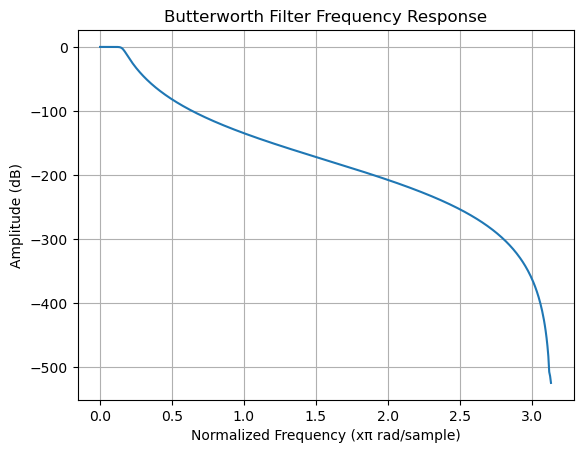

In [ ]:
n = np.arange(len(r))
r_I =  2 * r * np.cos(2 * np.pi * fc * n / fs)
r_Q = -2 * r * np.sin(2 * np.pi * fc * n / fs)
from scipy.signal import butter, freqz, lfilter

b, a = butter(8, 0.05)
r_I_filt = lfilter(b, a, r_I)
r_Q_filt = lfilter(b, a, r_Q)

#Plot the amplitude frequency response of the filter

w, h = freqz(b, a)
plt.plot(w, 20 * np.log10(abs(h)))
plt.title('Butterworth Filter Frequency Response')
plt.xlabel('Normalized Frequency (xπ rad/sample)')
plt.ylabel('Amplitude (dB)')
plt.grid()
plt.show()

It shows how the filter attenuates different frequencies, with the x-axis representing the normalized frequency and the y-axis representing the amplitude in decibels (dB). The plot helps to visualize the characteristics of the Butterworth filter, such as its cutoff frequency and roll-off rate. High frequency components are attenuated, while low frequency components are preserved, which is characteristic of a low-pass filter. The cutoff frequency is around 0.05 times the Nyquist frequency, which corresponds to the normalized cutoff frequency used in the Butterworth filter design.

**A/D Conversion and Down Sampling**